# Session 15 - Viola Jones object detection - review the ensembling

## Latency + Throughput + Confidence + Predict Probability

1-Latency : Latency in machine learning refers to the time delay between when a model receives an input (request) and when it produces the corresponding output (prediction/response). It's essentially the response time of your ML system. :

Inference Latency

Time taken for a single prediction:

Input → Model → Output

Among traditional/fundamental ML models (not deep learning), KNN has the highest inference latency

------------

2-Throughput: Throughput in ML is the number of predictions/inferences a model can process per unit of time (e.g., per second).


 If a model processes 1000 images in 10 seconds, throughput = 100 images/second.

and latency here is = 10/1000 s

------------

3-Inference : Inference is the deployment/usage phase where the model is actually put to work, and it's where latency and throughput matter most.

Inference technology: is about taking your trained deep learning model and making it run fast enough for real-world use (apps, websites, self-driving cars, etc.).


--------------------

4- Predict Probability and Confidence:

Probabilities give you flexibility to set your own decision threshold based on risk tolerance, not just a binary yes/no answer.

Confidence = how certain the model is about its prediction (final class not all score of classes), usually expressed as a probability score from 0 to 1 (or 0% to 100%).

------

Point for Ensembling:

for ensembling in classification, you should use probabilities instead of hard class predictions.
 for example in stacking Richer information for meta-model so better prediction







In [1]:
## Practicing argsort,argmin/max
import numpy as np
X = np.array([[10,100,2,200,34,45,22,33]])

print(X.argsort())# from min to max based on the indexes

print(X.argmin(axis=1))

print(X.argmax(axis=1))


[[2 0 6 7 4 5 1 3]]
[2]
[3]


## ensembling

In [4]:
#bagging overview function

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from scipy.stats import mode
# Bagging
X,y = [], []

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()
model3 = SVC()

model1.fit(X,y)
model2.fit(X,y)
model3.fit(X,y)

y_pred_1 = model1.predict(X)
y_pred_2 = model2.predict(X)
y_pred_3 = model3.predict(X)

# Most Frequent
y_pred = mode([y_pred_1, y_pred_2, y_pred_3])


# how it actually works - We used Probability

### Olivetti face prctice

(400, 4096)


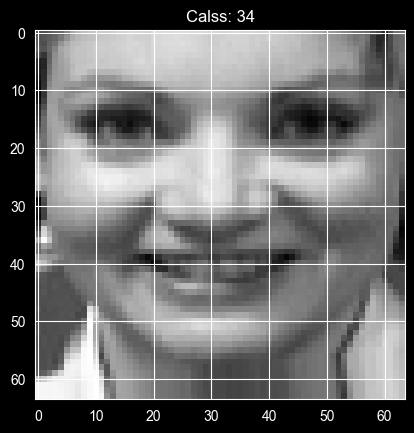

In [2]:
## Take Probability example
from sklearn.datasets import fetch_olivetti_faces
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

data  = fetch_olivetti_faces()

X = data.data
y = data.target
print(X.shape)

plt.imshow(X[340].reshape(64,64),cmap='gray')
plt.title(f'Calss: {y[340]}')
plt.show()


In [3]:
np.unique(y, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39]),
 array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10]))

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
clf = SVC(probability=True)

clf.fit(X, y)
y_pred = clf.predict(X)

print(classification_report(y, y_pred))



C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00        10
          16       1.00      1.00      1.00        10
          17       1.00    

In [5]:
cm = confusion_matrix(y, y_pred)
#sns.heatmap(cm, annot=True,cmap='Blues')
print(cm[25])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 9 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]


In [6]:
wrong_X = np.where(y != y_pred)
print(wrong_X)
print(y[250:260])
print(y_pred[250:260])

(array([256]),)
[25 25 25 25 25 25 25 25 25 25]
[25 25 25 25 25 25 22 25 25 25]


Text(0.5, 1.0, 'Calss: 25')

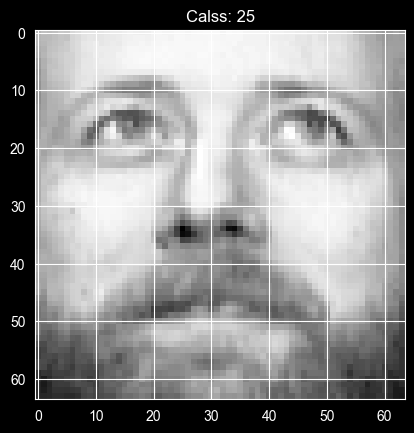

In [7]:
plt.imshow(X[256].reshape(64,64),cmap='gray')
plt.title(f'Calss: {y[256]}')

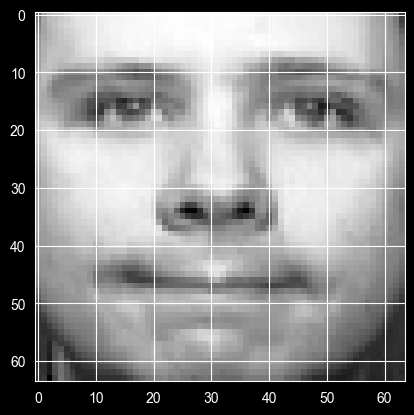

In [8]:
np.where(y==22)
plt.imshow(X[220].reshape(64,64),cmap='gray')

In [9]:
# confidence method
confidence = np.max(clf.predict_proba([X[256]]))
print(confidence)

predict=clf.predict([X[256]])
print(predict)
 #wron

0.16046911419238422
[22]


In [10]:
# avoid the bad result to client
if confidence >.4:
    print(predict)
else:
    print("Not sure !")

Not sure !


In [11]:
confidence = np.max(clf.predict_proba([X[256]]))
print(confidence)

predict=clf.predict([X[256]])
print(predict)
 #wron

if confidence >.4:
    print(predict)
    plt.imshow(X[256].reshape(64,64),cmap='gray')
else:
    print("Not sure !")

0.16046911419238422
[22]
Not sure !


0.4886474391607911
[25]
[25]


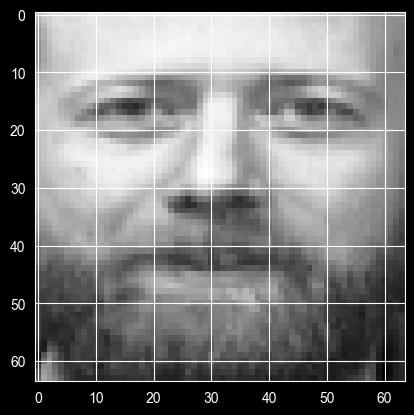

In [12]:
# but  true
confidence = np.max(clf.predict_proba([X[250]]))
print(confidence)

predict=clf.predict([X[250]])
print(predict)
 #true


if confidence >.4:
    print(predict)
    plt.imshow(X[250].reshape(64,64),cmap='gray')
else:
    print("Not sure !")

 question
input_size = (60000,28,28)

classes = 10

probabilities.shape

answer is (60000,10)

### Stacking practice

In [24]:
# Classification
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base models
model1 = LogisticRegression(max_iter=1000)
model2 = DecisionTreeClassifier(random_state=42)
model3 = SVC( probability=True,random_state=42)

# Meta model
meta_model = LogisticRegression(max_iter=1000)

# Stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ("lr", model1),
        ("dt", model2),
        ("svm", model3)
    ],
    final_estimator=meta_model,
    stack_method="predict_proba"
)

# Train
stacking_clf.fit(X_train, y_train)

# Predict
y_pred = stacking_clf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.4f}")
print(f"Predictions: {y_pred}")
print(f"Actual: {y_test}")

Classification Accuracy: 1.0000
Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [13]:
# Regression
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base models
model1 = LinearRegression()
model2 = DecisionTreeRegressor(random_state=42)
model3 = SVR()

# Meta model
meta_model = Ridge()

# Stacking regressor
stacking_reg = StackingRegressor(
    estimators=[
        ("lr", model1),
        ("dt", model2),
        ("svr", model3)
    ],
    final_estimator=meta_model,
    cv=5  # Cross-validation folds
)

# Train
stacking_reg.fit(X_train, y_train)

# Predict
y_pred = stacking_reg.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Regression MSE: {mse:.4f}")
print(f"Regression R² Score: {r2:.4f}")
print(f"Predictions: {y_pred[:5]}")
print(f"Actual: {y_test[:5]}")

Regression MSE: 0.3847
Regression R² Score: 0.7064
Predictions: [0.55106263 1.47898647 3.85170305 2.50721673 2.43653134]
Actual: [0.477   0.458   5.00001 2.186   2.78   ]


## Object Detection - Viola Jones

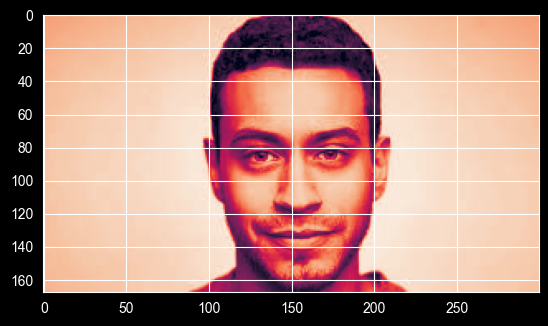

In [33]:
#Manual
import cv2
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

img = cv2.imread("face.png",cv2.IMREAD_GRAYSCALE)
plt.imshow(img)

Text(0.5, 1.0, 'Integral Image')

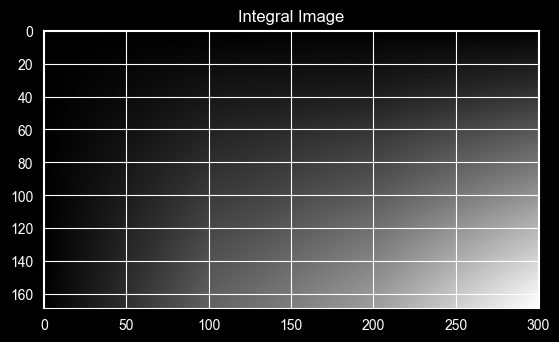

In [34]:
# integral
integral_img = cv2.integral(img)

# Show integral
plt.imshow(integral_img, cmap='gray')
plt.title('Integral Image')

In [47]:
# make haar-feature like
kerenl = np.array([
    [-1,-1,-1],
    [-1,-1,-1],
    [1,1,1],
    [1,1,1]
])

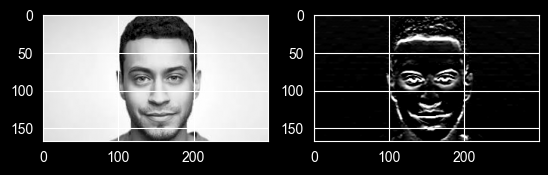

In [48]:
# pass the kernel in the window image
filtered_img = cv2.filter2D(img,-1,kerenl)

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.subplot(1,2,2)
plt.imshow(filtered_img, cmap="gray")
plt.show()

### Viola Jones

In [1]:
import cv2

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")


capture = cv2.VideoCapture(0)

while True:
    ret, frame = capture.read()

    faces = face_cascade.detectMultiScale(frame, 1.3)

    for x,y,w,h in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)

    cv2.imshow("Live", frame)
    if cv2.waitKey(1) == 'q':
        break


cv2.destroyAllWindows()
capture.release()


# https://docs.opencv.org/3.4.0/dc/d88/tutorial_traincascade.html

# https://machinelearningmastery.com/training-a-haar-cascade-object-detector-in-opencv/